In [2]:
import os
import torch
from torch import nn
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import numpy as np
from torchinfo import summary

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [6]:
class MLP(nn.Module):
    '''
    Multilayer Perceptron.
    '''
    def __init__(self, input_features=12, num_classes=2):  # Assuming 12 input features, 2 output classes
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_features, 48),  # 12 features as input
            nn.ReLU(),  # ReLU activation
            nn.Linear(48, 12),
            nn.ReLU(),
            nn.Linear(12, num_classes)  # Output layer: num_classes based on your dataset
        )

    def forward(self, x):
        '''Forward pass'''
        return self.layers(x)

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer):
    # Début de la boucle d'entraînement
    size = len(dataloader.dataset)  # Taille totale du jeu de données
    nb_batches = len(dataloader)     # Nombre total de lots dans le jeu de données
    epoch_loss = 0                   # Initialisation de la perte totale pour l'époque

    for batch, (X, y) in enumerate(dataloader):
        # X : données d'entrée, y : étiquettes correspondantes

        # Calcul de la prédiction du modèle et de la perte
        pred = model(X.float())  # Utilisation du modèle pour prédire les sorties
        loss = loss_fn(pred, y)  # Calcul de la perte entre les prédictions et les étiquettes réelles
        epoch_loss += loss.item()  # Ajout de la perte de ce lot à la perte totale de l'époque

        # Rétropropagation (Backpropagation)
        optimizer.zero_grad()  # Réinitialisation des gradients accumulés dans les paramètres du modèle
        loss.backward()       # Calcul des gradients par rétropropagation
        optimizer.step()       # Mise à jour des paramètres du modèle en fonction des gradients

    # Calcul de la perte moyenne pour l'époque et affichage
    average_loss = epoch_loss / nb_batches
    #print(f"\nPerte d'entraînement :", average_loss)

    # Retourne la perte moyenne pour l'époque
    return average_loss

def valid_loop(dataloader, model, loss_fn):
    # Début de la boucle de validation
    size = len(list(dataloader.dataset))  # Taille totale du jeu de données de validation
    nb_batches = len(dataloader)           # Nombre total de lots dans le jeu de données
    valid_loss = 0                         # Initialisation de la perte de validation

    with torch.no_grad():
        # Désactive le calcul des gradients pendant la validation
        for X, y in dataloader:
            # X : données d'entrée, y : étiquettes correspondantes

            # Calcul de la prédiction du modèle et de la perte
            pred = model(X.float())  # Utilisation du modèle pour prédire les sorties
            valid_loss += loss_fn(pred, y).item()  # Ajout de la perte de ce lot à la perte totale de validation

    # Calcul de la perte moyenne de validation et affichage
    valid_loss /= nb_batches
    #print("Perte de validation :", valid_loss)

    # Retourne la perte moyenne de validation
    return valid_loss

def perf_loop(dataloader, model):
    # Début de la boucle de performance
    Total = len(list(dataloader.dataset))  # Nombre total d'exemples dans le jeu de données de test
    nb_batches = len(dataloader)            # Nombre total de lots dans le jeu de données
    Positifs = 0                            # Initialisation du compteur de prédictions correctes

    with torch.no_grad():
        # Désactive le calcul des gradients pendant la performance
        for X, y in dataloader:
            # X : données d'entrée, y : étiquettes correspondantes

            # Calcul de la prédiction du modèle
            pred = model(X.float())  # Utilisation du modèle pour prédire les sorties

            # Calcul des probabilités de classe avec Softmax
            prob_pred = nn.Softmax(dim=1)(pred)

            # Prédiction de la classe avec la probabilité maximale
            y_pred = torch.argmax(prob_pred, dim=1)

            # Comparaison des prédictions avec les étiquettes réelles
            similaires = np.array(y_pred == y)
            Positifs += np.sum(similaires)

    # Retourne le nombre total de prédictions correctes, le nombre total d'exemples, et la dernière prédiction
    return Positifs, Total, y_pred

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:


dataset

In [10]:
torch.manual_seed(42) #Set fixed random number seed

import torch
from torch.utils.data import Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler  # Optional, for scaling features

class CSVDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        # Load the CSV file using pandas
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
        # Optional: Scale the features if necessary (e.g., StandardScaler)
        self.features = self.data.iloc[:, :-1].values  # All columns except the last (features)
        self.labels = self.data.iloc[:, -1].values    # The last column (labels)
        
        # Optionally, scale features (e.g., z-score normalization)
        self.scaler = StandardScaler()
        self.features = self.scaler.fit_transform(self.features)

    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.data)

    def __getitem__(self, idx):
        # Get a sample (features and label) from the dataset
        features = self.features[idx]
        label = self.labels[idx]
        
        # Convert to tensors
        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)  # For classification tasks
        
        if self.transform:
            # If there are any other transformations to apply
            features = self.transform(features)

        return features, label

# Example of how to use the custom dataset
csv_file = 'train.csv'
transform = None  # No transforms are needed for tabular data by default
dataset = CSVDataset(csv_file=csv_file, transform=transform)

# Check the dataset size
print(len(dataset))

# Example of how to iterate through the DataLoader
for features, labels in train_loader:
    # Your training code here
    print(features.shape, labels.shape)
    break  # Just printing the first batch shape for verification

print(train_loader)


2190
torch.Size([64, 12]) torch.Size([64])


In [15]:
N = len(dataset)
N_train = int(N * 0.9)
N_valid = N - N_train
BATCH_SIZE = 64 
EPOCHS = 60 
LEARNING_RATE = 1e-3 
OPTIM = "ADAM" 
Model_name = "Mon_meilleur_MLP"

# Create a DataLoader
from torch.utils.data import DataLoader
train_dataset, valid_dataset = random_split(dataset, [N_train, N_valid])
trainloader = DataLoader(dataset, batch_size=64, shuffle=True)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
print(train_loader)

In [13]:
dim = 12
summary(model=MLP(input_features = dim),
        input_size=(BATCH_SIZE, 1, 12), # (batch_size, input_channels, img_width, img_height)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
MLP (MLP)                                [64, 1, 12]          [64, 1, 2]           --                   True
├─Sequential (layers)                    [64, 1, 12]          [64, 1, 2]           --                   True
│    └─Linear (0)                        [64, 1, 12]          [64, 1, 48]          624                  True
│    └─ReLU (1)                          [64, 1, 48]          [64, 1, 48]          --                   --
│    └─Linear (2)                        [64, 1, 48]          [64, 1, 12]          588                  True
│    └─ReLU (3)                          [64, 1, 12]          [64, 1, 12]          --                   --
│    └─Linear (4)                        [64, 1, 12]          [64, 1, 2]           26                   True
Total params: 1,238
Trainable params: 1,238
Non-trainable params: 0
Total mult-adds (M): 0.08
Input size (MB): 0.00
Forward/bac

  3%|▎         | 2/60 [00:00<00:11,  4.87it/s]

best validation loss : 0.4182874485850334


  5%|▌         | 3/60 [00:00<00:13,  4.27it/s]

best validation loss : 0.3749220222234726


  7%|▋         | 4/60 [00:00<00:13,  4.04it/s]

...

best validation loss : 0.29571790993213654


 92%|█████████▏| 55/60 [00:11<00:01,  4.96it/s]

best validation loss : 0.2842874526977539


100%|██████████| 60/60 [00:11<00:00,  5.02it/s]


Apprentisage terminé.



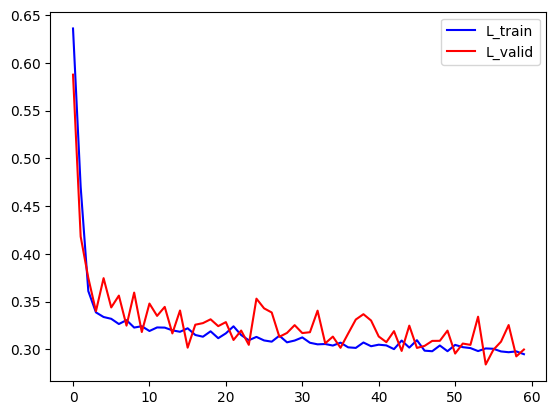

In [16]:
#################  Instanciation du MLP #################
dim = 12
my_MLP = MLP(input_features = dim)
my_loss = nn.CrossEntropyLoss()
if OPTIM == "SGD":
    my_optimizer = torch.optim.SGD(my_MLP.parameters(), lr=LEARNING_RATE)
elif OPTIM == "ADAM":
    my_optimizer = torch.optim.Adam(my_MLP.parameters(), lr=LEARNING_RATE)
else:
    print("Optimiseur inconnu !!!!")

############      BOUCLES D'APPRENTISSAGE     ###########
train_loss = []
valid_loss = []
for t in tqdm(range(EPOCHS)):
    train_loss.append(train_loop(trainloader, my_MLP, my_loss, my_optimizer))
    # on test à chaque itération
    valid_loss.append(valid_loop(validloader, my_MLP, my_loss))
    # mettre ici le Early Stopping
    if t == 0:
        best_valid_loss = valid_loss[-1]
    else:
        if valid_loss[-1] < best_valid_loss:
            best_valid_loss = valid_loss[-1]
            print(f"best validation loss : {best_valid_loss}")
            # on mémorise ce modèle
            best_iter = t
            torch.save(my_MLP.state_dict(), Model_name)

print('Apprentisage terminé.\n')

# visu des loss train et test
plt.figure()
plt.plot(train_loss,"b",label="L_train")
plt.plot(valid_loss,"r",label="L_valid")
plt.legend()

In [ ]:
############## on teste maintenaant les performances ################
test_dataset = MNIST(os.getcwd(), train = False, download=True, transform=transforms.ToTensor())
test_dataset = CSVDataset(csv_file=csv_file, transform=transform)
N_test = len(test_dataset)

##############
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=N_test, shuffle=False, num_workers=1)
affichage(testloader,"Test :")

my_best_MLP = MLP(input_features = dim)
my_best_MLP.load_state_dict(torch.load(Model_name))
Positifs, Total, y_pred = perf_loop(testloader, my_best_MLP)
print("Taux de reco en Test:",Positifs,"/", Total, "=", (Positifs/Total)*100, "% de réussite")
print("Meilleure époque :",best_iter+1)

nb_train_param = count_parameters(my_best_MLP)
print("Nombre de paramètres libres:",nb_train_param)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 3605483.92it/s]


Extracting /home/ENT-UR/AUTOFS/STUDENTS/coelhrod/Git/Apprentissage profond/Project/MNIST/raw/train-images-idx3-ubyte.gz to /home/ENT-UR/AUTOFS/STUDENTS/coelhrod/Git/Apprentissage profond/Project/MNIST/raw



KeyboardInterrupt: 